In [1]:
#from datamatrix import io, operations as ops, NAN
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns


In [13]:
## load data from https://ess.sikt.no/
data_path = os.path.dirname('~/Data/ESS/')
ess_datafile = 'ESS1e06_7-ESS2e03_6-ESS3e03_7-ESS4e04_6-ESS5e03_6-ESS6e02_7-ESS7e02_3-ESS8e02_3-ESS9e03_3-ESS10e03_3-ESS10SCe03_2-ESS11e04_1.csv'

dm = pd.read_csv(os.path.join(data_path, ess_datafile), 
                            usecols=['essround', 'cntry', 'pbldmn', 'pspwght', 'pweight', 'inwyys'])

In [ ]:
# preprocess
# ESS missing codes for pbldmn: 7=Refusal, 8=Don't know, 9=No answer
dm = dm[dm.pbldmn < 7]
dm = dm[dm.pbldmn < 7]

# Recode 1=Yes -> 1.0, 2=No -> 0.0  (so the mean = proportion 'yes')
dm['protested'] = (dm.pbldmn == 1) * 1.0

# input the years
round_to_year = {1: 2002, 2: 2004, 3: 2006, 4: 2008, 5: 2010,
                 6: 2012, 7: 2014, 8: 2016, 9: 2018, 10: 2020, 11: 2023}
dm['year'] = dm['essround'].map(round_to_year)

# Combined survey weight (post-strat × population size = comparable across countries)
dm.anweight = dm.pspwght * dm.pweight 
protest_weighted   = dm.groupby['year'].agg(dm.protested, weights=dm.anweight)


/var/folders/_j/yr2dhh6s7cddw6tgb11rm8gm0000gn/T/ipykernel_27661/1515497323.py:15: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  dm.anweight = dm.pspwght * dm.pweight


TypeError: 'method' object is not subscriptable

In [37]:
dm

,essround,cntry,pspwght,pweight,pbldmn,inwyys,year,protested
0,1,AT,0.940933,0.271487,2.0,NaN,2002,0.0
1,1,AT,0.470466,0.271487,1.0,NaN,2002,1.0
2,1,AT,1.392155,0.271487,2.0,NaN,2002,0.0
3,1,AT,1.382163,0.271487,2.0,NaN,2002,0.0
4,1,AT,1.437766,0.271487,2.0,NaN,2002,0.0
...,...,...,...,...,...,...,...,...
430865,9,SK,0.654094,0.424138,2.0,2019.0,2018,0.0
430866,9,SK,0.730359,0.424138,2.0,2019.0,2018,0.0
430867,9,SK,0.363919,0.424138,2.0,2019.0,2018,0.0
430868,9,SK,0.632651,0.424138,2.0,2019.0,2018,0.0


<Axes: xlabel='year', ylabel='protested'>

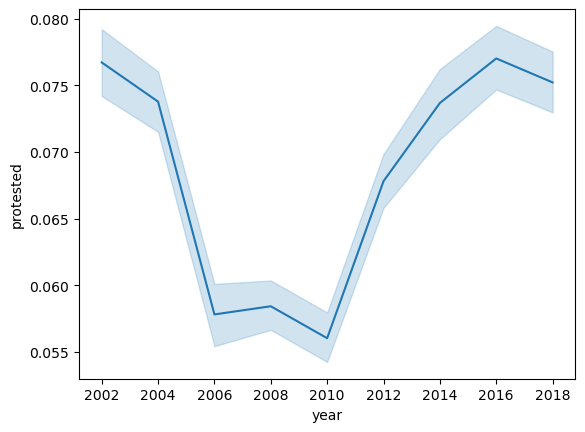

In [35]:
sns.lineplot(data=dm, x='year', y='protested')